# 02 — GA Loop & Elitism Test

Verify that the full GA pipeline works end-to-end and that elitism behaves correctly:
- Best fitness should never get worse between generations (with elitism >= 1)
- Compare runs with different elite sizes
- Visualise the best individual over generations

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from src.ga import run_ga
from src.fitness import load_target
from src.rendering import render_individual

%matplotlib inline
plt.rcParams["figure.dpi"] = 120

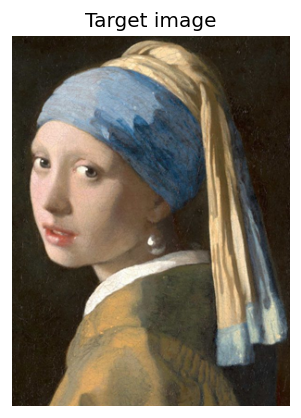

In [2]:
target = load_target(os.path.join("..", "data", "target.png"))

plt.figure(figsize=(3, 4))
plt.imshow(target)
plt.title("Target image")
plt.axis("off")
plt.show()

## 1. Basic GA run — verify the loop works

In [3]:
best_ind, best_fit, history = run_ga(
    target_image=target,
    pop_size=30,
    generations=50,
    selection_method="tournament",
    crossover_method="single_point",
    crossover_rate=0.8,
    mutation_method="gaussian",
    mutation_rate=0.1,
    sigma=10.0,
    elite_size=1,
    seed=42
)
print(f"Final best RMSE: {best_fit:.4f}")

Generation 1/50 | Best: 69.9124 | Avg: 78.4740
Generation 2/50 | Best: 68.9650 | Avg: 75.6901
Generation 3/50 | Best: 68.9650 | Avg: 74.3505
Generation 4/50 | Best: 68.4924 | Avg: 73.7223
Generation 5/50 | Best: 68.4924 | Avg: 72.0654
Generation 6/50 | Best: 67.1608 | Avg: 71.0082
Generation 7/50 | Best: 67.1608 | Avg: 71.1280
Generation 8/50 | Best: 67.1349 | Avg: 70.4364
Generation 9/50 | Best: 67.1349 | Avg: 70.9429
Generation 10/50 | Best: 66.6603 | Avg: 70.2770
Generation 11/50 | Best: 66.6603 | Avg: 69.7483
Generation 12/50 | Best: 66.4094 | Avg: 69.6939
Generation 13/50 | Best: 66.3453 | Avg: 69.0054
Generation 14/50 | Best: 66.0835 | Avg: 68.6946
Generation 15/50 | Best: 65.8663 | Avg: 68.3129
Generation 16/50 | Best: 64.6632 | Avg: 67.9863
Generation 17/50 | Best: 64.6632 | Avg: 68.2043
Generation 18/50 | Best: 62.5766 | Avg: 67.4951
Generation 19/50 | Best: 62.5766 | Avg: 67.2206
Generation 20/50 | Best: 62.4883 | Avg: 66.4986
Generation 21/50 | Best: 62.4510 | Avg: 66.5325
G

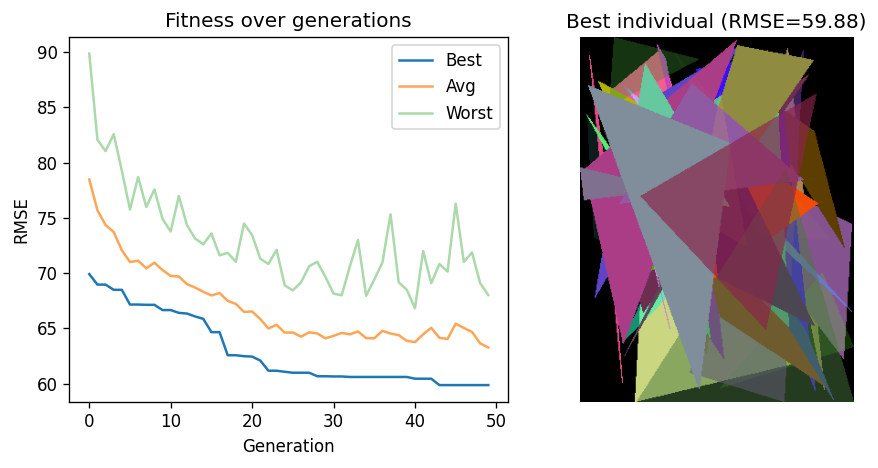

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].plot(history["best_fitness"], label="Best")
axes[0].plot(history["avg_fitness"], label="Avg", alpha=0.7)
axes[0].plot(history["worst_fitness"], label="Worst", alpha=0.4)
axes[0].set_xlabel("Generation")
axes[0].set_ylabel("RMSE")
axes[0].set_title("Fitness over generations")
axes[0].legend()

axes[1].imshow(render_individual(best_ind))
axes[1].set_title(f"Best individual (RMSE={best_fit:.2f})")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## 2. Elitism guarantee check

With `elite_size >= 1`, the best fitness should **never increase** (get worse) from one generation to the next.

In [5]:
best_series = np.array(history["best_fitness"])
diffs = np.diff(best_series)
violations = np.sum(diffs > 0)

print(f"Generations where best fitness got worse: {violations}")
if violations == 0:
    print("Elitism is working correctly — best fitness is monotonically non-increasing.")
else:
    print("WARNING: Elitism may be broken! Best fitness increased in some generations.")
    bad_gens = np.where(diffs > 0)[0]
    for g in bad_gens[:10]:
        print(f"  Gen {g} -> {g+1}: {best_series[g]:.4f} -> {best_series[g+1]:.4f}")

Generations where best fitness got worse: 0
Elitism is working correctly — best fitness is monotonically non-increasing.


## 3. Compare different elite sizes

Run the GA with elite_size = 0 (no elitism), 1, and 3 to see the effect.

In [6]:
elite_sizes = [0, 1, 3]
results = {}

for es in elite_sizes:
    print(f"\n--- Running with elite_size={es} ---")
    ind, fit, hist = run_ga(
        target_image=target,
        pop_size=30,
        generations=50,
        selection_method="tournament",
        crossover_method="single_point",
        crossover_rate=0.8,
        mutation_method="gaussian",
        mutation_rate=0.1,
        sigma=10.0,
        elite_size=es,
        seed=42
    )
    results[es] = {"individual": ind, "fitness": fit, "history": hist}


--- Running with elite_size=0 ---
Generation 1/50 | Best: 69.9124 | Avg: 78.4740
Generation 2/50 | Best: 68.9650 | Avg: 75.7427
Generation 3/50 | Best: 68.7852 | Avg: 73.8550
Generation 4/50 | Best: 67.3886 | Avg: 72.6023
Generation 5/50 | Best: 68.3367 | Avg: 72.6853
Generation 6/50 | Best: 69.1937 | Avg: 72.2522
Generation 7/50 | Best: 69.4566 | Avg: 72.3675
Generation 8/50 | Best: 69.3430 | Avg: 72.6584
Generation 9/50 | Best: 67.7852 | Avg: 71.5226
Generation 10/50 | Best: 68.5296 | Avg: 72.4749
Generation 11/50 | Best: 68.3210 | Avg: 72.0620
Generation 12/50 | Best: 67.4984 | Avg: 71.7593
Generation 13/50 | Best: 66.4648 | Avg: 71.1387
Generation 14/50 | Best: 65.9656 | Avg: 71.1184
Generation 15/50 | Best: 66.6714 | Avg: 70.2434
Generation 16/50 | Best: 66.3967 | Avg: 69.8573
Generation 17/50 | Best: 65.0192 | Avg: 69.5967
Generation 18/50 | Best: 65.0735 | Avg: 69.6662
Generation 19/50 | Best: 65.0557 | Avg: 70.0713
Generation 20/50 | Best: 63.6630 | Avg: 69.9183
Generation 21/

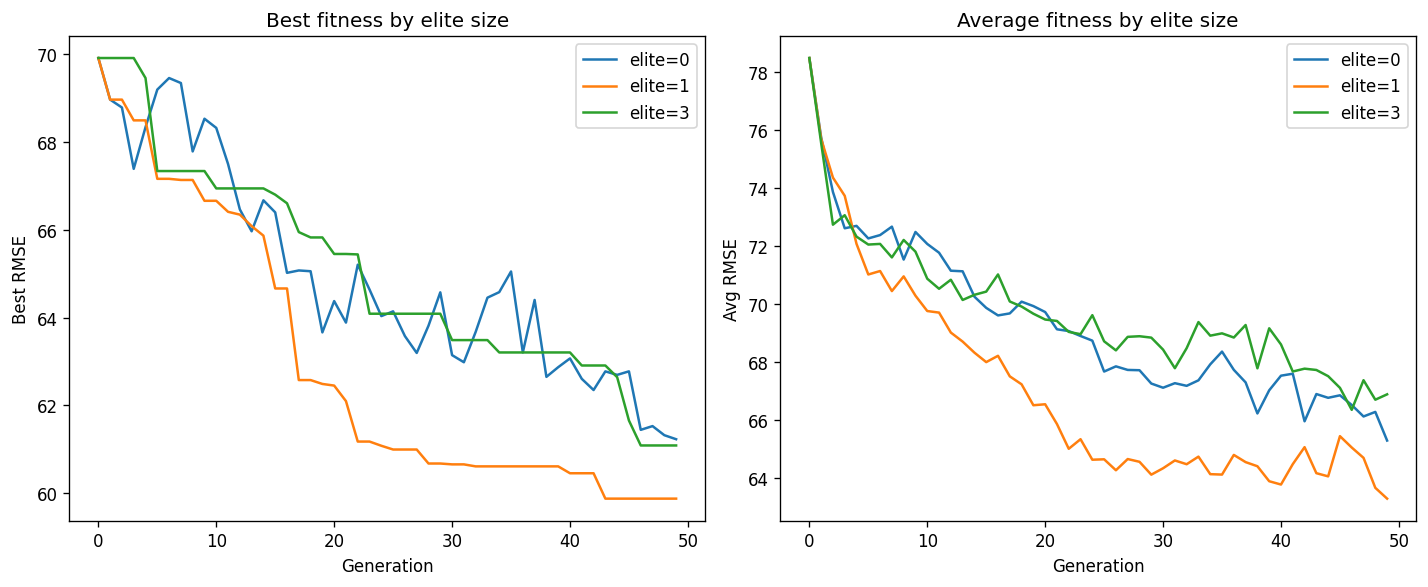

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for es in elite_sizes:
    axes[0].plot(results[es]["history"]["best_fitness"], label=f"elite={es}")
axes[0].set_xlabel("Generation")
axes[0].set_ylabel("Best RMSE")
axes[0].set_title("Best fitness by elite size")
axes[0].legend()

for es in elite_sizes:
    axes[1].plot(results[es]["history"]["avg_fitness"], label=f"elite={es}")
axes[1].set_xlabel("Generation")
axes[1].set_ylabel("Avg RMSE")
axes[1].set_title("Average fitness by elite size")
axes[1].legend()

plt.tight_layout()
plt.show()

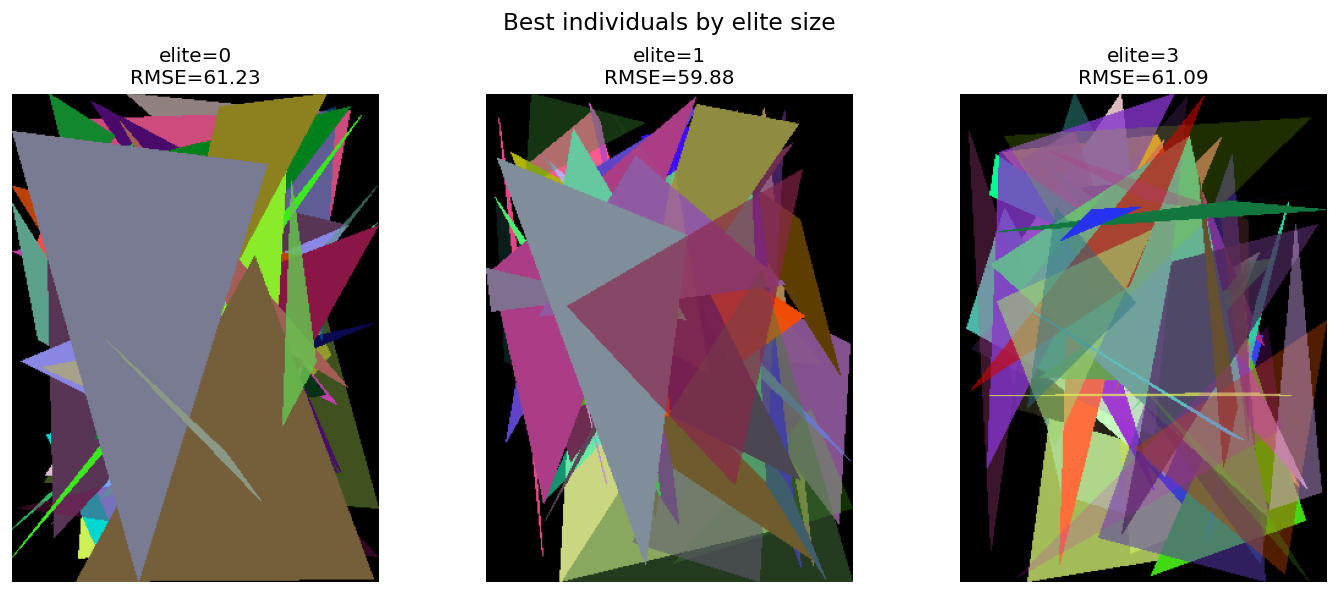

In [8]:
fig, axes = plt.subplots(1, len(elite_sizes), figsize=(4 * len(elite_sizes), 5))

for i, es in enumerate(elite_sizes):
    img = render_individual(results[es]["individual"])
    axes[i].imshow(img)
    axes[i].set_title(f"elite={es}\nRMSE={results[es]['fitness']:.2f}")
    axes[i].axis("off")

plt.suptitle("Best individuals by elite size", fontsize=14)
plt.tight_layout()
plt.show()

## 4. Elitism monotonicity check across all runs

In [9]:
for es in elite_sizes:
    best_series = np.array(results[es]["history"]["best_fitness"])
    violations = np.sum(np.diff(best_series) > 0)
    status = "OK" if violations == 0 else f"FAIL ({violations} violations)"
    print(f"elite_size={es}: {status} | final RMSE={results[es]['fitness']:.4f}")

elite_size=0: FAIL (21 violations) | final RMSE=61.2292
elite_size=1: OK | final RMSE=59.8757
elite_size=3: OK | final RMSE=61.0871
